In [35]:
!pip install datasets


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [37]:

dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())


                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [38]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


(16000, 2)
(2000, 2)


(2000, 2)

In [39]:
emotion_names = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [40]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])



**Tokenization**

In [41]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token="")

tokenizer.fit_on_texts(train_df["text"])



**Converting tokens to sequence**

**Padding**

In [42]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])


**Building the model**



In [43]:
max_length = max([len(x) for x in X_train])

X_train_padded = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test, maxlen=max_length, padding='post')

model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=64)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(32, activation="relu")
)

model.add(
    Dense(6, activation="softmax")
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Compiling the model**

In [44]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Training the model**

In [57]:
history = model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.3373 - loss: 1.5771 - val_accuracy: 0.3262 - val_loss: 1.5742
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.3374 - loss: 1.5776 - val_accuracy: 0.3262 - val_loss: 1.5735
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.3376 - loss: 1.5764 - val_accuracy: 0.3262 - val_loss: 1.5728
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.3383 - loss: 1.5756 - val_accuracy: 0.3250 - val_loss: 1.5754
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.3385 - loss: 1.5744 - val_accuracy: 0.3244 - val_loss: 1.5757
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.3394 - loss: 1.5718 - val_accuracy: 0.3253 - val_loss: 1.5747
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.3405 - loss: 1.5694 - val_accuracy: 0.3250 - val_loss: 1.5752
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.3404 - loss: 1.5671 - v

**Accuracy Plot**

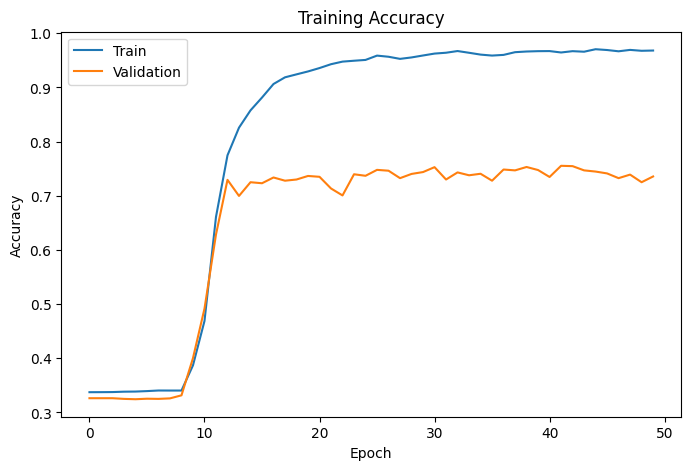

In [58]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

**Loss Plot**

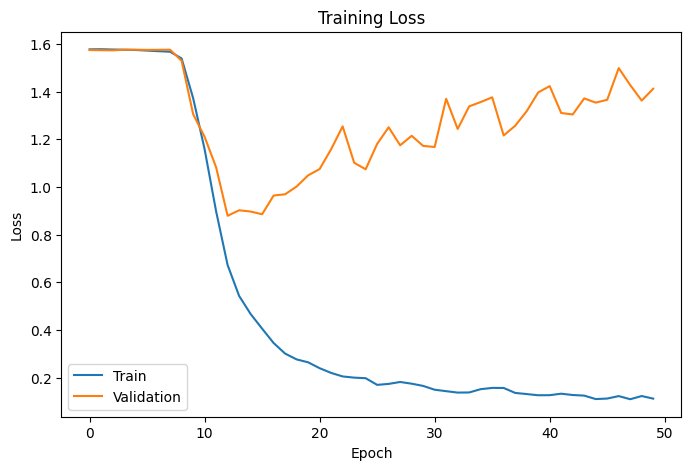

In [59]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()



**Evaluation Of Model**

In [48]:
loss, accuracy = model.evaluate(X_test_padded, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3475 - loss: 1.5597
Test Accuracy : 0.3474999964237213


**Classification Model**

In [49]:
pred = model.predict(X_test_padded)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       275
           1       0.00      0.00      0.00       224
           2       0.35      1.00      0.52       695
           3       0.00      0.00      0.00       159
           4       0.00      0.00      0.00       581
           5       0.00      0.00      0.00        66

    accuracy                           0.35      2000
   macro avg       0.06      0.17      0.09      2000
weighted avg       0.12      0.35      0.18      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Predicting your own sentence**

In [60]:
sentence = ["i didnt feel sad"]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Emotion: sadness
